In [11]:
from pathlib import Path
import sys
import math

planning_path = Path('.').absolute().parents[0] / 'cloud_auto_park'
print(planning_path)

sys.path.append(str(planning_path))

from trajectory_utils import *


/project/project/sim_ws/src/digital_twin/cloud_auto_park/cloud_auto_park


In [12]:
x_sep = 2.0
y_sep = 3.5
obb_1 = OrientedBoundingBox(x_sep, y_sep, 4.0, 2.0, math.pi/2)
obb_2 = OrientedBoundingBox(x_sep + 6.0, y_sep, 4.0, 2.0, math.pi/2)
wall = OrientedBoundingBox(5.0, -4.0, 12.0, 1.0, 0.0)
obstacles = [obb_1, obb_2, wall]
# obstacles = [obb_1, obb_2]
desired_pose = OrientedBoundingBox(x_sep + 3.0, y_sep, 4.0, 2.0, math.pi/2)


In [13]:
traj_optimizer = TrajectoryOptimizer(method='BFGS')
traj_optimizer.generate_optimal_trajectory(desired_pose, obstacles)


/usr/local/lib/python3.8/dist-packages/scipy/optimize/_minimize.py:569: RuntimeWarning: Method BFGS cannot handle bounds.
  warn('Method %s cannot handle bounds.' % method,


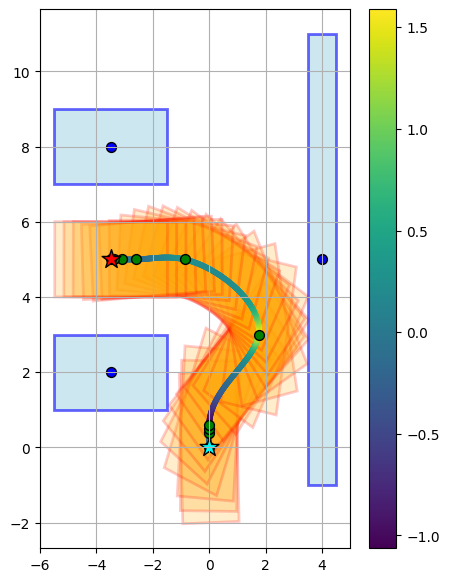

In [14]:
plot_desired_path(traj_optimizer.initial_traj, obstacles, num_intermediate_ego=30)


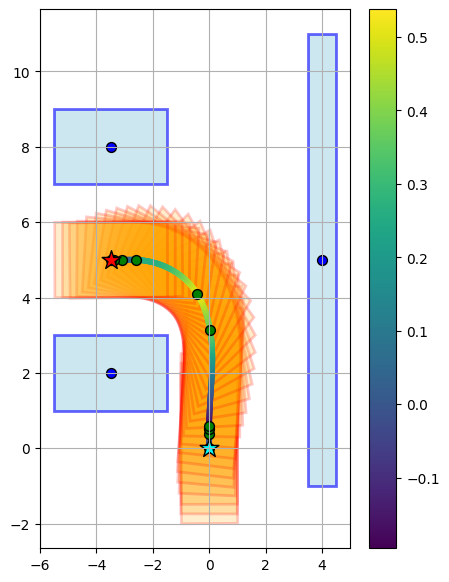

In [15]:
plot_desired_path(traj_optimizer.optimized_traj, obstacles, num_intermediate_ego=30)
